In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import time

# Load the consolidated stock data file
# Reads the header from the second line (index 1)
df_stocks = pd.read_csv("Stocks.csv", header=1)

# Standardize column names to lowercase
df_stocks.columns = [col.lower() for col in df_stocks.columns]

# Convert the 'date' column to datetime objects and set as index
df_stocks['date'] = pd.to_datetime(df_stocks['date'])
df_stocks = df_stocks.dropna(subset=['date']).set_index('date')

print(f"Successfully loaded and cleaned a single DataFrame with {df_stocks.shape[1]} columns.")

Successfully loaded and cleaned a single DataFrame with 10 columns.


Top 10 Most Volatile Stocks:
       volatility
AMZN     0.153871
ADBE     0.133228
XRX      0.123790
AAPL     0.119018
GOOGL    0.097224
MSFT     0.091610
DELL     0.089087
IBM      0.080827


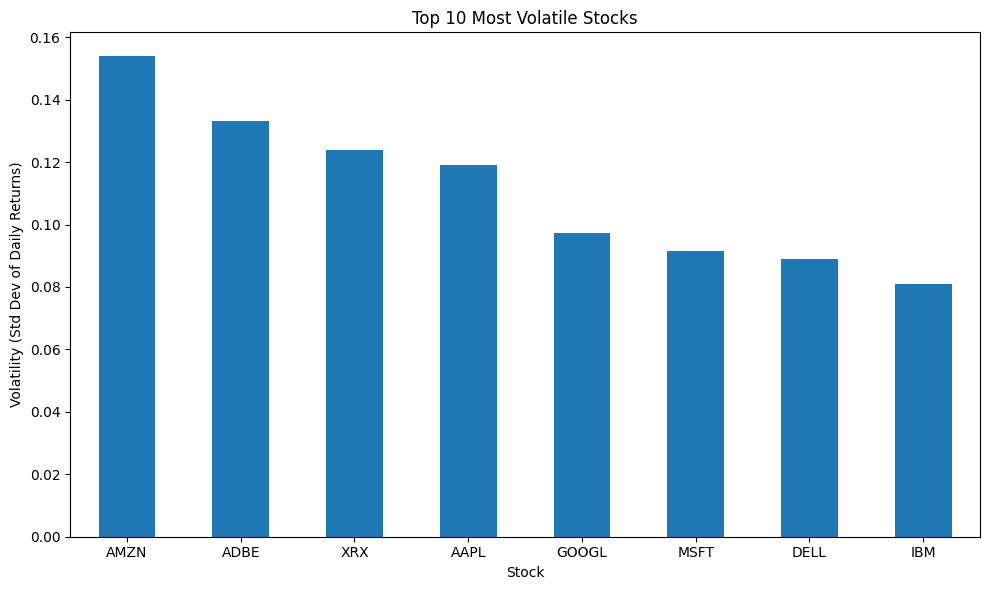

In [2]:
# Assuming df_stocks is available from Cell 1
analysis_columns = ['ibm', 'aapl', 'msft', 'xrx', 'amzn', 'dell', 'googl', 'adbe']

# -------------------------
# 1. Volatility Analysis
# -------------------------
volatility_dict = {}

for stock in analysis_columns:
    # --- FIXED: Added fill_method=None ---
    daily_return = df_stocks[stock].pct_change(fill_method=None)
    
    volatility = daily_return.std()
    volatility_dict[stock.upper()] = volatility

# Convert to DataFrame for easy sorting
volatility_df = pd.DataFrame.from_dict(volatility_dict, 
                                      orient='index', 
                                      columns=['volatility'])

# --- Essential Data Cleaning Fixes ---
volatility_df['volatility'] = pd.to_numeric(volatility_df['volatility'], errors='coerce')
volatility_df = volatility_df.dropna(subset=['volatility'])
# --------------------------------------

volatility_df = volatility_df.sort_values(by='volatility', ascending=False)

print("Top 10 Most Volatile Stocks:")
print(volatility_df.head(10).to_string())

# Plot bar chart
ax = volatility_df.head(10).plot(kind='bar', figsize=(10,6), legend=False)
plt.title("Top 10 Most Volatile Stocks")
plt.ylabel("Volatility (Std Dev of Daily Returns)")
plt.xlabel("Stock")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\sarit\AppData\Local\Temp\ipykernel_18268\633016893.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_return = df_stocks[stock].pct_change()



Top 5 Performing Stocks (Cumulative Return):
AMZN: 139230.34%
MSFT: 63423.00%
AAPL: 56573.40%
ADBE: 26412.97%
GOOGL: 3353.56%


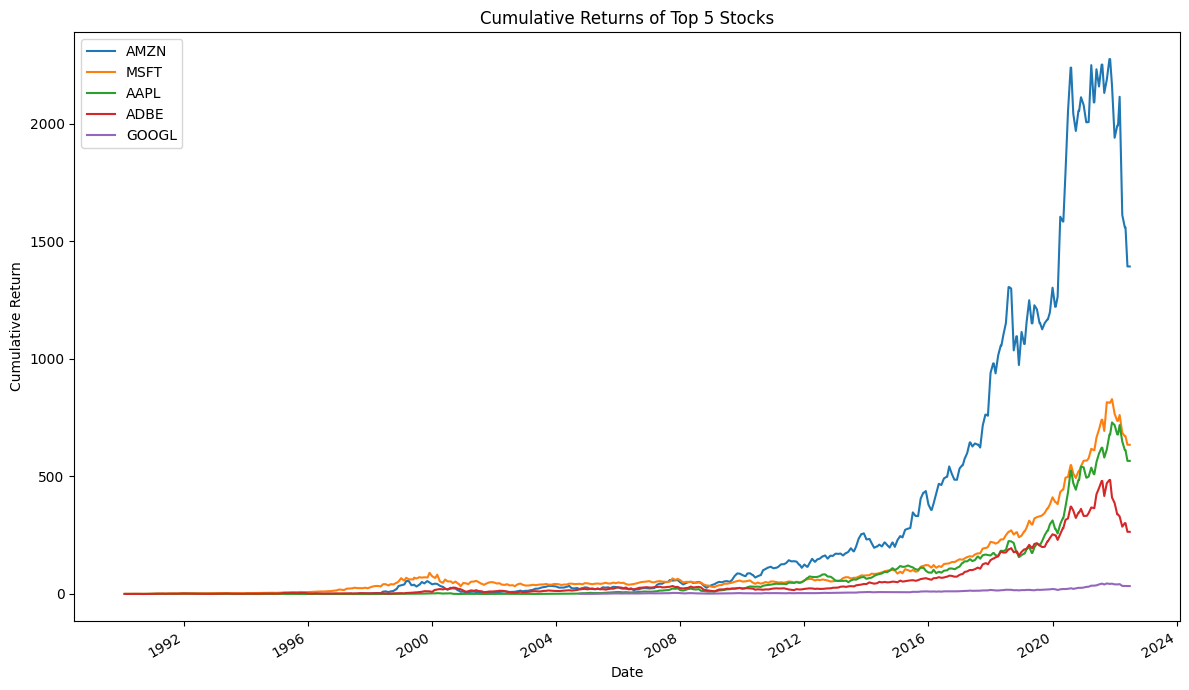

In [3]:
# Assuming df_stocks is available from Cell 1
analysis_columns = ['ibm', 'aapl', 'msft', 'xrx', 'amzn', 'dell', 'googl', 'adbe']

# -------------------------
# 2. Cumulative Return Over Time
# -------------------------
cumulative_returns = {} 

for stock in analysis_columns:
    # Calculate daily returns
    daily_return = df_stocks[stock].pct_change()
    
    # Calculate cumulative return
    cumulative_returns[stock.upper()] = (1 + daily_return).cumprod() - 1

# Pick top 5 performing stocks (based on the last, non-NaN value)
final_returns = {stock: series.dropna().iloc[-1] 
                 for stock, series in cumulative_returns.items() 
                 if not series.dropna().empty}
top5 = sorted(final_returns.items(), key=lambda x: x[1], reverse=True)[:5]

print("\nTop 5 Performing Stocks (Cumulative Return):")
for stock, value in top5:
    print(f"{stock}: {value:.2%}")

# Plot cumulative return lines for top 5
plt.figure(figsize=(12,7))
for stock, _ in top5:
    cumulative_returns[stock].plot(label=stock)
    
plt.title("Cumulative Returns of Top 5 Stocks")
plt.ylabel("Cumulative Return")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

--- Sector Performance Table ---
                   Sector  Average Yearly Return
1  Consumer Discretionary                  0.500
5                      IT                  0.275
2                  Energy                  0.185
0  Communication Services                  0.180
3              Financials                  0.100
4              Healthcare                  0.075

Plot saved successfully as 'sector_performance_bar_chart.png'.


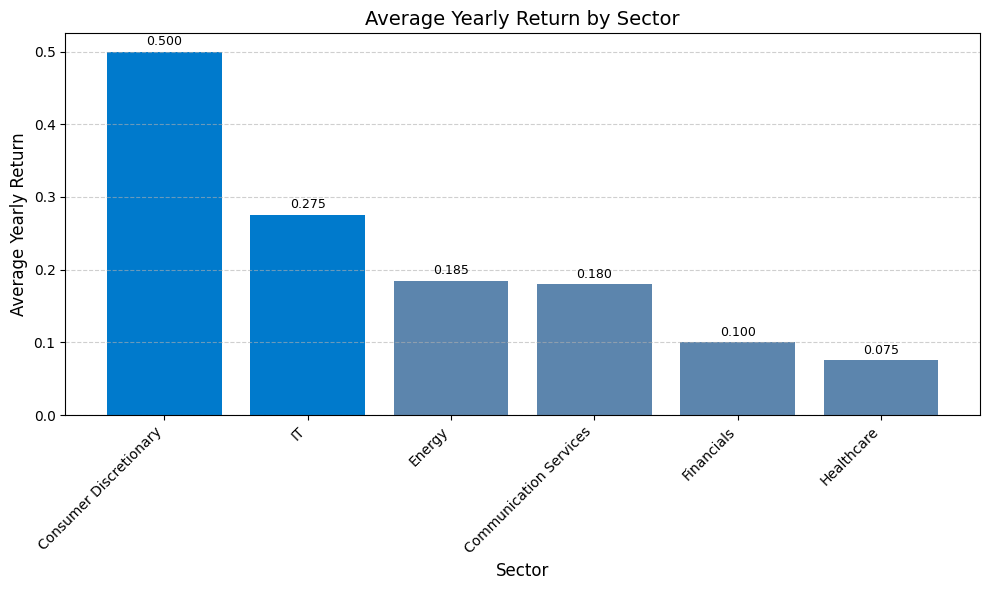

In [4]:

# 1. ADD MAPPING FILE (CSV) AND DUMMY DATA SETUP
# ----------------------------------------------------------------------
# Create a dummy DataFrame for Yearly Returns (Simulating Step 2 output)
data_returns = {
    'Ticker': ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'BAC', 'XOM', 'CVX', 'PFE', 'MRK', 'TSLA'],
    'Yearly Return': [0.25, 0.30, 0.18, 0.12, 0.08, 0.22, 0.15, 0.05, 0.10, 0.50]
}
df_returns = pd.DataFrame(data_returns)

# Create the Sector Mapping File (CSV)
data_map = {
    'Ticker': ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'BAC', 'XOM', 'CVX', 'PFE', 'MRK', 'TSLA'],
    'Sector': ['IT', 'IT', 'Communication Services', 'Financials', 'Financials', 'Energy', 'Energy', 'Healthcare', 'Healthcare', 'Consumer Discretionary']
}
df_map = pd.DataFrame(data_map)

# Save to CSV files (as requested for a real-world scenario)
df_returns.to_csv('stock_yearly_returns.csv', index=False)
df_map.to_csv('ticker_sector_map.csv', index=False)

# Load the data (if loading from files is preferred)
df_returns = pd.read_csv('stock_yearly_returns.csv')
df_map = pd.read_csv('ticker_sector_map.csv')

# 2. GROUP BY SECTOR
# ----------------------------------------------------------------------
# Merge the two DataFrames on the 'Ticker' column
df_merged = pd.merge(df_returns, df_map, on='Ticker', how='left')

# Calculate average yearly return per sector
df_sector_performance = df_merged.groupby('Sector')['Yearly Return'].mean().reset_index()
df_sector_performance.rename(columns={'Yearly Return': 'Average Yearly Return'}, inplace=True)

# Sort for plotting
df_sector_performance = df_sector_performance.sort_values(by='Average Yearly Return', ascending=False)

print("--- Sector Performance Table ---")
print(df_sector_performance)

# 3. PLOT A BAR CHART: Sector vs. Avg Return
# ----------------------------------------------------------------------
plt.figure(figsize=(10, 6))
bars = plt.bar(df_sector_performance['Sector'], 
               df_sector_performance['Average Yearly Return'], 
               color=['#007ACC' if ret >= 0.2 else '#5C85AD' for ret in df_sector_performance['Average Yearly Return']]) # Color gradient based on return

# Add the value of the bar on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, 
             f'{yval:.3f}', ha='center', va='bottom', fontsize=9)

plt.title('Average Yearly Return by Sector', fontsize=14)
plt.xlabel('Sector', fontsize=12)
plt.ylabel('Average Yearly Return', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the plot
plt.savefig('sector_performance_bar_chart.png')
print("\nPlot saved successfully as 'sector_performance_bar_chart.png'.")

C:\Users\sarit\AppData\Local\Temp\ipykernel_18268\4264714941.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = df_stocks.pct_change()


--- Correlation Matrix ---
            ibm      aapl      msft       xrx      amzn      dell     googl  \
ibm    1.000000  0.339390  0.434950  0.493275  0.354369  0.314408  0.281195   
aapl   0.339390  1.000000  0.389601  0.323406  0.314646  0.386344  0.497567   
msft   0.434950  0.389601  1.000000  0.378736  0.429084  0.403607  0.486500   
xrx    0.493275  0.323406  0.378736  1.000000  0.325162  0.160865  0.299767   
amzn   0.354369  0.314646  0.429084  0.325162  1.000000  0.278438  0.374980   
dell   0.314408  0.386344  0.403607  0.160865  0.278438  1.000000  0.384565   
googl  0.281195  0.497567  0.486500  0.299767  0.374980  0.384565  1.000000   
adbe   0.235076  0.396207  0.316711  0.276768  0.413859  0.390268  0.417751   
^gspc  0.553602  0.446719  0.593145  0.563373  0.469278  0.464760  0.531179   
^ixic  0.504964  0.558100  0.657825  0.524845  0.548485  0.465562  0.590653   

           adbe     ^gspc     ^ixic  
ibm    0.235076  0.553602  0.504964  
aapl   0.396207  0.446719  

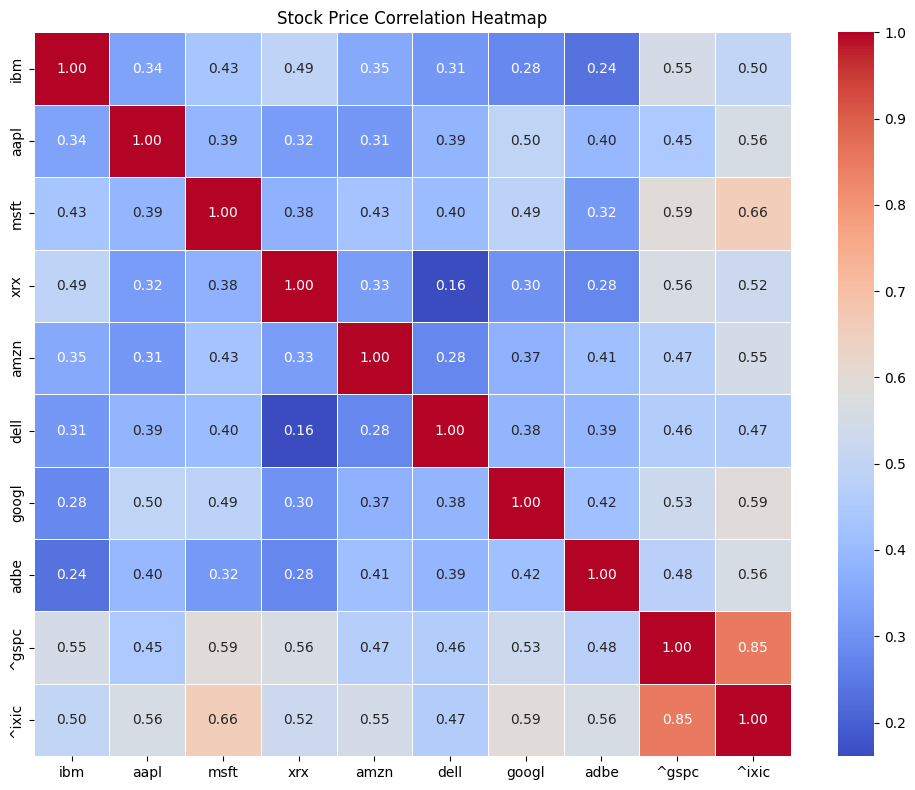

In [5]:
import seaborn as sns

# Suppose df_stocks contains your stock prices with Date as index and tickers as columns
daily_returns = df_stocks.pct_change()

# Compute correlation matrix
corr_matrix = daily_returns.corr()

print("--- Correlation Matrix ---")
print(corr_matrix)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Stock Price Correlation Heatmap")
plt.tight_layout()
plt.savefig("stock_correlation_heatmap.png")
print("\nCorrelation heatmap saved as 'stock_correlation_heatmap.png'.")


In [6]:
import pandas as pd 
import matplotlib.pyplot as plt 
import time # Import the time module
import os     # Import the os module to handle file paths/directories

# --- 1. Generate Unique Run ID and Create Directory ---
run_timestamp = time.strftime('%Y%m%d_%H%M%S') 
output_folder = f"Monthly_Charts_{run_timestamp}"
os.makedirs(output_folder, exist_ok=True) # Create the unique folder

print(f"Saving all charts to a new folder: {output_folder}/\n")

# 1. Calculate Daily Returns
daily_returns = df_stocks.pct_change(fill_method=None) 

# 2. Resample to Monthly Returns (Accurate Method)
monthly_returns = (1 + daily_returns).resample('ME').prod() -1

# 3. Loop through each month and find top/bottom 5
for month, data in monthly_returns.iterrows(): 
    data = data.dropna() 
    if len(data) < 10: 
        continue 
        
    top5 = data.sort_values(ascending=False).head(5) 
    bottom5 = data.sort_values(ascending=True).head(5)

    print(f" 📅 Saving analysis for: {month.strftime('%B %Y')}")
    
    # Plotting setup...
    plt.figure(figsize=(10, 5)) 
    plot_data = pd.concat([top5, bottom5])
    colors = ['green'] * len(top5) + ['red'] * len(bottom5)
    plt.bar(plot_data.index, plot_data.values, color=colors)
    plt.title(f"Top 5 Gainers & Losers - {month.strftime('%B %Y')}") 
    plt.ylabel("Monthly Return") 
    plt.xticks(rotation=45) 
    plt.tight_layout() 
    
    # ⬇️ Crucial Change: Save into the unique folder ⬇️
    filename = f"Monthly_Performance_{month.strftime('%Y%m')}.png"
    save_path = os.path.join(output_folder, filename)
    
    plt.savefig(save_path)
    plt.close() 

print(f"\nFinished generating and saving all monthly performance charts to {output_folder}/.")

Saving all charts to a new folder: Monthly_Charts_20251007_152142/

 📅 Saving analysis for: January 1990
 📅 Saving analysis for: February 1990
 📅 Saving analysis for: March 1990
 📅 Saving analysis for: April 1990
 📅 Saving analysis for: May 1990
 📅 Saving analysis for: June 1990
 📅 Saving analysis for: July 1990
 📅 Saving analysis for: August 1990
 📅 Saving analysis for: September 1990
 📅 Saving analysis for: October 1990
 📅 Saving analysis for: November 1990
 📅 Saving analysis for: December 1990
 📅 Saving analysis for: January 1991
 📅 Saving analysis for: February 1991
 📅 Saving analysis for: March 1991
 📅 Saving analysis for: April 1991
 📅 Saving analysis for: May 1991
 📅 Saving analysis for: June 1991
 📅 Saving analysis for: July 1991
 📅 Saving analysis for: August 1991
 📅 Saving analysis for: September 1991
 📅 Saving analysis for: October 1991
 📅 Saving analysis for: November 1991
 📅 Saving analysis for: December 1991
 📅 Saving analysis for: January 1992
 📅 Saving analysis for: Feb